# Feature Engineering

## Objective

This notebook transforms the raw Barclays PLC **2015–2024** data into a modelling dataset for predicting whether the **next trading day's closing price is higher than the current day's closing price**.

The engineered predictors represent four ideas motivated by the exploratory analysis:

- **trend / relative price position**;
- **recent returns and short-horizon dependence**;
- **recent volatility**; and
- **recent price momentum**.



## 1. Setup and data loading


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(
    "barclays_stock_data.csv",
    index_col="Date",
    parse_dates=True
).sort_index()

print(f"Observations: {len(data):,}")
print(f"Period: {data.index.min().date()} to {data.index.max().date()}")
print(f"Duplicated dates: {data.index.duplicated().sum()}")
print(f"Missing raw values: {data.isna().sum().sum()}")

data.head()


Observations: 2,526
Period: 2015-01-02 to 2024-12-31
Duplicated dates: 0
Missing raw values: 0


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,242.199997,245.600006,241.550003,243.149994,20219711
2015-01-05,242.300003,243.149994,234.199997,234.699997,39050852
2015-01-06,234.050003,235.850006,230.250000,230.350006,37573308
2015-01-07,232.100006,233.460007,230.149994,230.600006,37219841
2015-01-08,234.300003,238.350006,231.550003,237.050003,41082776


## 2. Trend and relative-price features


In [11]:
# Moving averages summarise short- and medium-term price levels.
data["MA5"] = data["Close"].rolling(window=5).mean()
data["MA20"] = data["Close"].rolling(window=20).mean()

# Relative trend measures are less dependent on the absolute share-price
# level and therefore have a clearer interpretation across different
# price regimes.
data["Price_to_MA5"] = data["Close"] / data["MA5"] - 1
data["Price_to_MA20"] = data["Close"] / data["MA20"] - 1
data["MA5_to_MA20"] = data["MA5"] / data["MA20"] - 1

data[
    ["Close", "MA5", "MA20", "Price_to_MA5", "Price_to_MA20", "MA5_to_MA20"]
].head(25)


,Close,MA5,MA20,Price_to_MA5,Price_to_MA20,MA5_to_MA20
Date,,,,,,
2015-01-02,243.149994,NaN,NaN,NaN,NaN,NaN
2015-01-05,234.699997,NaN,NaN,NaN,NaN,NaN
2015-01-06,230.350006,NaN,NaN,NaN,NaN,NaN
2015-01-07,230.600006,NaN,NaN,NaN,NaN,NaN
2015-01-08,237.050003,235.170001,NaN,0.007994,NaN,NaN
2015-01-09,231.000000,232.740002,NaN,-0.007476,NaN,NaN
2015-01-12,231.399994,232.080002,NaN,-0.002930,NaN,NaN
2015-01-13,233.000000,232.610001,NaN,0.001677,NaN,NaN
2015-01-14,223.550003,231.200000,NaN,-0.033088,NaN,NaN


A **moving average (MA)** is the average closing price over a specified number of recent trading days. It smooths short-term price movements and provides a simple measure of the recent price trend.

For example, the **5-day moving average (MA5)** at time $t$ is:

$$
\text{MA5}_t = \frac{1}{5}\sum_{i=0}^{4}\text{Close}_{t-i}
$$

Raw moving averages largely track the absolute Barclays share-price level. The modelling predictors therefore use **relative deviations** from the moving averages.

For example:

$$
\text{Price-to-MA20}_t = \frac{\text{Close}_t}{\text{MA20}_t} - 1
$$

This measures how far the current closing price is above or below its recent 20-day average.

A positive value means the price is **above** its 20-day average, while a negative value means it is **below**. Expressing the feature as a relative deviation captures trend information without directly encoding the absolute share-price level.

The relationship between the short- and longer-term moving averages is captured by:

$$
\text{MA5-to-MA20}_t = \frac{\text{MA5}_t}{\text{MA20}_t} - 1
$$

A positive value means the **5-day moving average is above the 20-day moving average**, while a negative value means it is below. This captures the relationship between short- and longer-term price trends without relying on absolute price levels.

## 3. Return and volatility features


In [12]:
# Current-day log return. At the intended prediction time (after today's
# close), both Close_t and Close_{t-1} are already observed.
data["LogReturn"] = np.log(data["Close"] / data["Close"].shift(1))

# Rolling standard deviations capture the time-varying volatility observed
# during EDA. The current day's return is included because it is known at
# the prediction timestamp.
data["Vol10"] = data["LogReturn"].rolling(window=10).std()
data["Vol20"] = data["LogReturn"].rolling(window=20).std()

data[["LogReturn", "Vol10", "Vol20"]].head(25)


,LogReturn,Vol10,Vol20
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.035370,NaN,NaN
2015-01-06,-0.018708,NaN,NaN
2015-01-07,0.001085,NaN,NaN
2015-01-08,0.027586,NaN,NaN
2015-01-09,-0.025853,NaN,NaN
2015-01-12,0.001730,NaN,NaN
2015-01-13,0.006891,NaN,NaN
2015-01-14,-0.041403,NaN,NaN


## 4. Lagged-return features


In [13]:
# Recent historical returns allow the models to test whether short-horizon
# price movements contain information about next-day direction.
for lag in [1, 2, 3, 5]:
    data[f"LagRet_{lag}"] = data["LogReturn"].shift(lag)

data[
    ["LogReturn", "LagRet_1", "LagRet_2", "LagRet_3", "LagRet_5"]
].head(10)


,LogReturn,LagRet_1,LagRet_2,LagRet_3,LagRet_5
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.035370,NaN,NaN,NaN,NaN
2015-01-06,-0.018708,-0.035370,NaN,NaN,NaN
2015-01-07,0.001085,-0.018708,-0.035370,NaN,NaN
2015-01-08,0.027586,0.001085,-0.018708,-0.035370,NaN
2015-01-09,-0.025853,0.027586,0.001085,-0.018708,NaN
2015-01-12,0.001730,-0.025853,0.027586,0.001085,-0.035370
2015-01-13,0.006891,0.001730,-0.025853,0.027586,-0.018708
2015-01-14,-0.041403,0.006891,0.001730,-0.025853,0.001085


A **lagged return** is the log return observed a specified number of trading days earlier. For lag $k$, it is defined as:

$$
\text{LagRet}_{k,t} = r_{t-k}
$$

where $r_t$ is the current day's log return.

The features use lags of **1, 2, 3 and 5 trading days** to capture recent return history and test whether past returns contain information about next-day direction.

## 5. Momentum feature: RSI


In [14]:
def rsi(series, period=14):
    """Calculate a simple rolling Relative Strength Index (RSI)."""
    delta = series.diff()
    gains = delta.clip(lower=0)
    losses = -delta.clip(upper=0)

    avg_gain = gains.rolling(window=period).mean()
    avg_loss = losses.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


data["RSI14"] = rsi(data["Close"], period=14)

data[["Close", "RSI14"]].head(20)


,Close,RSI14
Date,,
2015-01-02,243.149994,NaN
2015-01-05,234.699997,NaN
2015-01-06,230.350006,NaN
2015-01-07,230.600006,NaN
2015-01-08,237.050003,NaN
2015-01-09,231.000000,NaN
2015-01-12,231.399994,NaN
2015-01-13,233.000000,NaN
2015-01-14,223.550003,NaN


The **Relative Strength Index (RSI)** is a momentum indicator that compares the magnitude of recent gains with recent losses.

For each trading day, the price change is:

$$
\Delta P_t = P_t - P_{t-1}
$$

The daily gain and loss are then defined as:

$$
\text{Gain}_t = \max(\Delta P_t, 0)
$$

$$
\text{Loss}_t = \max(-\Delta P_t, 0)
$$

The **average gain** and **average loss** are the simple rolling averages of these values over the previous 14 trading days:

$$
\text{Average Gain}_{14,t}
= \frac{1}{14}\sum_{i=0}^{13}\text{Gain}_{t-i}
$$

$$
\text{Average Loss}_{14,t}
= \frac{1}{14}\sum_{i=0}^{13}\text{Loss}_{t-i}
$$

These are used to calculate relative strength:

$$
RS_t = \frac{\text{Average Gain}_{14,t}}
{\text{Average Loss}_{14,t}}
$$

and the 14-day RSI:

$$
RSI_t = 100 - \frac{100}{1 + RS_t}
$$

The RSI is bounded between **0 and 100**. Higher values indicate stronger recent gains relative to losses, while lower values indicate stronger recent losses. A value around **50** indicates that recent gains and losses have been more balanced.

This provides the model with a measure of **recent price momentum**.

## 6. Define the modelling predictors


In [15]:
features = [
    "Price_to_MA5",
    "Price_to_MA20",
    "MA5_to_MA20",
    "LogReturn",
    "Vol10",
    "Vol20",
    "LagRet_1",
    "LagRet_2",
    "LagRet_3",
    "LagRet_5",
    "RSI14"
]

print(f"Number of predictors: {len(features)}")

print("\nMissing values before cleaning:")
display(data[features].isna().sum().to_frame("Missing"))

Number of predictors: 11

Missing values before cleaning:


,Missing
Price_to_MA5,4
Price_to_MA20,19
MA5_to_MA20,19
LogReturn,1
Vol10,10
Vol20,20
LagRet_1,2
LagRet_2,3
LagRet_3,4
LagRet_5,6


The final predictor set contains **11 features** covering relative price trends, returns, volatility, lagged returns and momentum. 

## 7. Construct the next-day target


In [16]:
# Next trading day's closing price.
data["CloseNextDay"] = data["Close"].shift(-1)

# Target = 1 if the next trading day's close is higher than today's close;
# Target = 0 if it is lower or unchanged.
data["Target"] = (data["CloseNextDay"] > data["Close"]).astype(float)

# The final observation has no observed next-day close, so its target is
# genuinely unavailable rather than class 0.
data.loc[data["CloseNextDay"].isna(), "Target"] = np.nan

data[["Close", "CloseNextDay", "Target"]].tail(10)


,Close,CloseNextDay,Target
Date,,,
2024-12-16,270.299988,264.549988,0.0
2024-12-17,264.549988,267.049988,1.0
2024-12-18,267.049988,260.250000,0.0
2024-12-19,260.250000,260.250000,0.0
2024-12-20,260.250000,261.600006,1.0
2024-12-23,261.600006,263.549988,1.0
2024-12-24,263.549988,264.899994,1.0
2024-12-27,264.899994,264.750000,0.0
2024-12-30,264.750000,268.149994,1.0


### Leakage check

For a row dated \(t\):

- every predictor uses prices/returns observed no later than \(t\);
- `CloseNextDay` uses the close at \(t+1\), but is used **only to construct the target**;
- `CloseNextDay` is not included in the predictor matrix.

This preserves the intended forecasting direction: information available after today's close is used to predict whether tomorrow's close will be higher.


## 8. Create and validate the modelling dataset


In [17]:
model_data = data[features + ["Target"]].copy()

rows_before = len(model_data)
model_data = model_data.dropna().copy()
model_data["Target"] = model_data["Target"].astype(int)
rows_after = len(model_data)

print(f"Observations before cleaning: {rows_before:,}")
print(f"Observations after cleaning:  {rows_after:,}")
print(f"Observations removed:         {rows_before - rows_after:,}")
print(f"Final period: {model_data.index.min().date()} to {model_data.index.max().date()}")
print(f"Duplicate dates: {model_data.index.duplicated().sum()}")
print(f"Missing values remaining: {model_data.isna().sum().sum()}")
print(f"Target values: {sorted(model_data['Target'].unique())}")

model_data.head()


Observations before cleaning: 2,526
Observations after cleaning:  2,505
Observations removed:         21
Final period: 2015-01-30 to 2024-12-30
Duplicate dates: 0
Missing values remaining: 0
Target values: [np.int64(0), np.int64(1)]


,Price_to_MA5,Price_to_MA20,MA5_to_MA20,LogReturn,Vol10,Vol20,LagRet_1,LagRet_2,LagRet_3,LagRet_5,RSI14,Target
Date,,,,,,,,,,,,
2015-01-30,-0.014313,0.000342,0.014867,-0.010198,0.014707,0.019852,-0.001267,-0.010918,-0.005414,-0.001028,52.903909,1
2015-02-02,-0.003043,0.007357,0.010432,0.007234,0.012910,0.018295,-0.010198,-0.001267,-0.010918,-0.009919,53.003169,1
2015-02-03,0.042287,0.057088,0.014200,0.052046,0.019620,0.021068,0.007234,-0.010198,-0.001267,-0.005414,74.604749,1
2015-02-04,0.033229,0.054293,0.020387,0.001207,0.019549,0.021067,0.052046,0.007234,-0.010198,-0.010918,72.365602,1
2015-02-05,0.023026,0.051886,0.028210,0.000201,0.018463,0.020315,0.001207,0.052046,0.007234,-0.001267,78.463328,1


### Final data cleaning

The modelling dataset is restricted to the selected predictors and target. Observations containing missing values are then removed; these occur mainly at the beginning of the sample because the rolling and lagged features require sufficient prior trading-day data, with the final observation also lacking a next-day target. The remaining target values are converted to integers, and the final dataset is checked for missing values and duplicate dates.

## 9. Predictor correlation analysis


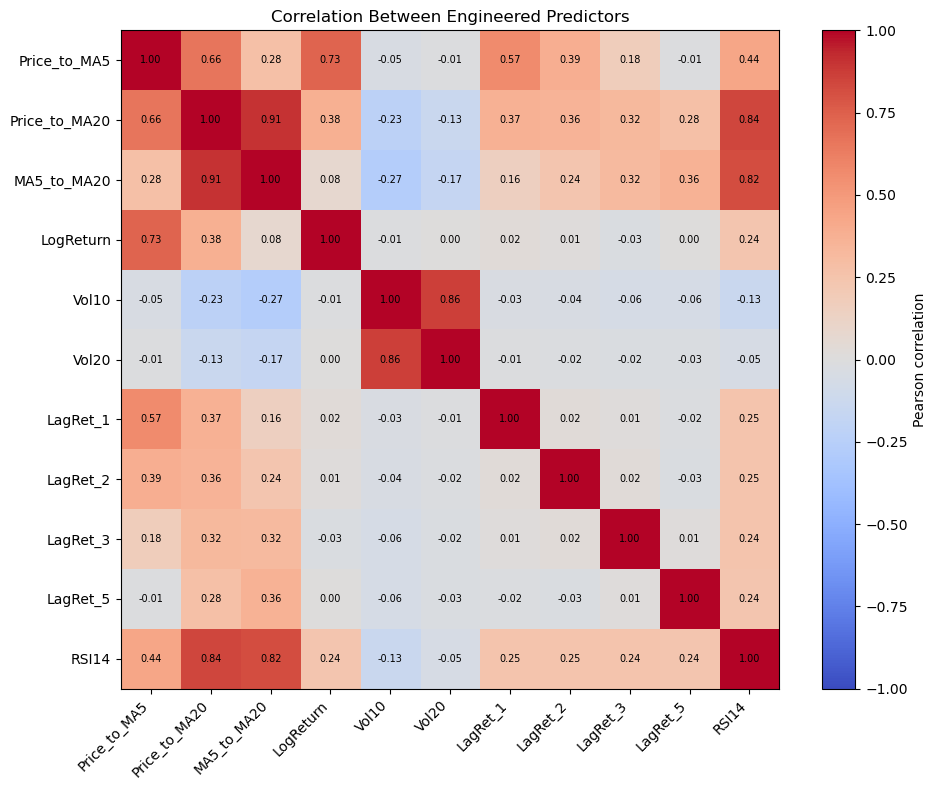

In [20]:
correlation_matrix = model_data[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center", va="center", fontsize=7
        )

plt.colorbar(image, ax=ax, label="Pearson correlation")
ax.set_title("Correlation Between Engineered Predictors")
plt.tight_layout()
plt.show()


The correlation matrix shows some strong relationships between predictors that measure similar aspects of recent price behaviour. In particular, `Price_to_MA20` is highly correlated with `MA5_to_MA20` (**0.91**) and `RSI14` (**0.84**), while `Vol10` and `Vol20` are also strongly correlated (**0.86**) due to their overlapping rolling windows.

These relationships indicate some redundancy among the engineered predictors. However, correlation is used here as a diagnostic rather than an automatic feature-selection rule; the usefulness of the predictors will ultimately be assessed during modelling and out-of-sample validation.

## 10. Save the prepared dataset


In [19]:
model_data.to_csv("barclays_model_data.csv")

print("Modelling dataset saved successfully.")
print("Final dataset shape:", model_data.shape)


Modelling dataset saved successfully.
Final dataset shape: (2505, 12)


## Feature-engineering summary

The final dataset contains **11 predictors** representing relative price trends, current and lagged returns, rolling volatility, and momentum. Relative moving-average features are used instead of raw moving-average levels to reduce dependence on the absolute Barclays share price. The binary target represents the following trading day's closing-price direction: **1** indicates that the next day's closing price is higher than the current day's close, while **0** indicates that it is lower or unchanged.

